In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.manifold import TSNE

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

I0000 00:00:1776527208.281811   23629 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776527208.327644   23629 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776527209.674562   23629 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [9]:
dataset_path = r"caltech-101"

In [10]:
selected_classes = ["airplanes", "accordion", "anchor"]

In [11]:
base_model = ResNet50(weights="imagenet", include_top=False, pooling='avg')
model = Model(inputs=base_model.input, outputs=base_model.output)


In [12]:
def extract_feature(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    feature = model.predict(img_array, verbose=0)
    return feature.flatten()

In [13]:
features = []
labels = []

In [14]:
for category in os.listdir(dataset_path):
    if category not in selected_classes:
        continue
    
    category_path = os.path.join(dataset_path, category)
    
    for img_name in tqdm(os.listdir(category_path)):
        img_path = os.path.join(category_path, img_name)
        
        try:
            feat = extract_feature(img_path)
            features.append(feat)
            labels.append(category)
        except:
            pass

100%|██████████| 42/42 [00:04<00:00, 10.20it/s]


In [15]:
features = np.array(features)
print("Total images processed:", len(features))

Total images processed: 897


In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

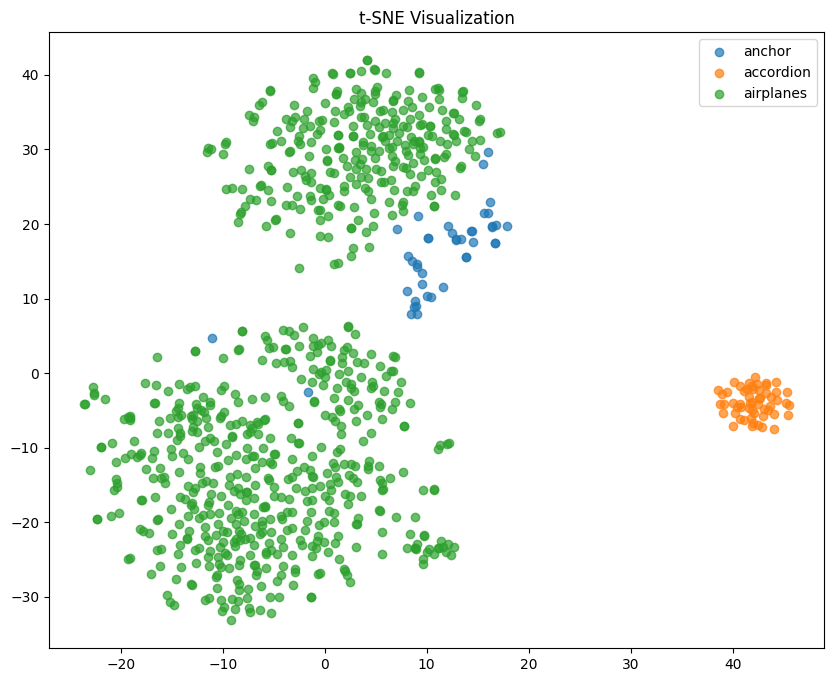

In [17]:
plt.figure(figsize=(10, 8))

unique_labels = list(set(labels))

for label in unique_labels:
    indices = [i for i in range(len(labels)) if labels[i] == label]
    
    plt.scatter(
        features_2d[indices, 0],
        features_2d[indices, 1],
        label=label,
        alpha=0.7
    )

plt.title("t-SNE Visualization")
plt.legend()
plt.show()